# A tuned mass damper: frequency response by dense LU, and H-infinity tuning

A mass on a spring without damping resonates without bound at its natural frequency. Den Hartog's
remedy is a small second mass, the absorber, hung on the first by a spring and a damper and tuned
near that frequency. This notebook computes the amplification of the forced primary mass over
frequency in real arithmetic with Scaly's dense LU, then tunes the absorber's frequency ratio and
damping for the smallest peak (the H-infinity norm on a frequency grid) with gradients taken
through the solves, and compares the result with Den Hartog's classical formulas.

| Scaly feature | Where |
| --- | --- |
| `sc.linalg.lu`: partial pivoting, the packed factor and its permutation row | One factorization, two inputs |
| `sc.linalg.lu_solve` with a matrix right-hand side, and with `trans=True` | One factorization, two inputs |
| `sc.linalg.solve(a, b, assume="gen")` and its implicit derivative | The magnitude over frequency, Tuning |
| `sc.vmap` over 400 frequencies | The magnitude over frequency |
| `sc.gradient` through the mapped solves and a `.max()` | Tuning |
| `write_module` | The generated C |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
import scaly as sc
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "integrators" / "frequency_response"

## The model

The primary mass $m_1 = 1$ sits on a spring $k_1 = 1$, natural frequency $\omega_1 = \sqrt{k_1/m_1} = 1$,
and is driven by a force $F$. The absorber of mass $m_2 = \mu m_1$, $\mu = 0.05$, hangs on it by a
spring $k_2 = m_2 (f \omega_1)^2$ and a damper $c_2 = 2 m_2 \zeta f \omega_1$, where $f$ is the tuning
ratio and $\zeta$ the absorber's damping ratio:

$$
\begin{aligned}
m_1 \ddot x_1 &= F - k_1 x_1 - k_2 (x_1 - x_2) - c_2 (\dot x_1 - \dot x_2), \\
m_2 \ddot x_2 &= k_2 (x_1 - x_2) + c_2 (\dot x_1 - \dot x_2).
\end{aligned}
$$

With the state $x = (x_1, x_2, \dot x_1, \dot x_2)$ this is $\dot x = A x + B F$, and $A$ is affine in
the absorber's two coefficients, $A = A_0 + k_2 A_{k} + c_2 A_{c}$. The output is the amplification
$k_1 x_1 / F$, so $C = (k_1, 0, 0, 0)$. The frequency response $G(j\omega) = C (j\omega I - A)^{-1} B$
is complex; in real arithmetic the phasor $x_r + j x_i$ of the state solves

$$
M(\omega) \begin{bmatrix} x_r \\ x_i \end{bmatrix} = \begin{bmatrix} B \\ 0 \end{bmatrix}, \qquad
M(\omega) = \begin{bmatrix} -A & -\omega I \\ \omega I & -A \end{bmatrix},
$$

and $G = C x_r + j\, C x_i$.

In [2]:
MU = 0.05
M1, K1 = 1.0, 1.0
M2, W1 = MU * M1, np.sqrt(K1 / M1)
A0 = np.array([[0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 1.0], [-K1 / M1, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0]])
A_K2 = np.array([[0.0] * 4, [0.0] * 4, [-1 / M1, 1 / M1, 0.0, 0.0], [1 / M2, -1 / M2, 0.0, 0.0]])
A_C2 = np.array([[0.0] * 4, [0.0] * 4, [0.0, 0.0, -1 / M1, 1 / M1], [0.0, 0.0, 1 / M2, -1 / M2]])
B = np.array([0.0, 0.0, 1 / M1, 0.0])
B_ABSORBER = np.array([0.0, 0.0, 0.0, 1 / M2])  # a force on the absorber, the second input
C = np.array([K1, 0.0, 0.0, 0.0])
INPUTS = np.concatenate([np.stack([B, B_ABSORBER], axis=1), np.zeros((4, 2))])  # [B; 0] for each input, (8, 2)
OUTPUTS = np.block([[C[:, None], np.zeros((4, 1))], [np.zeros((4, 1)), C[:, None]]])  # [C; 0] and [0; C], (8, 2)


def spring_damper(f, zeta):
  return M2 * (f * W1) ** 2, 2 * M2 * zeta * f * W1


def m_matrix(w, p):
  """M(w) for the tuning p = (f, zeta), as a Scaly expression."""
  k2, c2 = spring_damper(p[0], p[1])
  a = sc.const(A0) + k2 * sc.const(A_K2) + c2 * sc.const(A_C2)
  wi = w * sc.const(np.eye(4))
  return sc.concat([sc.concat([-a, -wi], axis=1), sc.concat([wi, -a], axis=1)], axis=0)


def response_numpy(ws, f, zeta, b=B):
  """G(jw) by NumPy's complex solve, np.linalg.solve(1j w I - A, b), one frequency per entry."""
  k2, c2 = spring_damper(f, zeta)
  a = A0 + k2 * A_K2 + c2 * A_C2
  x = np.linalg.solve(1j * ws[:, None, None] * np.eye(4) - a, np.broadcast_to(b[:, None], (ws.size, 4, 1)))
  return x[:, :, 0] @ C

## One factorization, two inputs, and the adjoint

The first row of $A$ is $(0, 0, 1, 0)$: a position has no diagonal term, so $M_{00} = 0$ and LU
without pivoting divides by zero at its first step. `sc.linalg.lu(M)` pivots by rows, $P M = L U$,
and returns one packed $(n + 1) \times n$ array: $L$ below the diagonal, $U$ on and above it, and in
the last row the permutation, entry $i$ the row of $M$ that became row $i$.

`lu_solve(packed, R)` then solves for a matrix of right-hand sides with the one factorization: here
two inputs, the force on the primary mass and a force on the absorber. With `trans=True` it solves
with $M^\top$, which gives the same responses from the other side,

$$
G_r = \begin{bmatrix} C & 0 \end{bmatrix} M^{-1} \begin{bmatrix} B \\ 0 \end{bmatrix}
= \Big(M^{-\top} \begin{bmatrix} C^\top \\ 0 \end{bmatrix}\Big)^{\!\top} \begin{bmatrix} B \\ 0 \end{bmatrix},
$$

one transposed solve per output (the real and the imaginary part) instead of one solve per input.
Den Hartog's tuning, below, is used here at $\omega = 0.95$.

In [3]:
F_DH, ZETA_DH = 1 / (1 + MU), np.sqrt(3 * MU / (8 * (1 + MU) ** 3))
W_POINT = 0.95


@sc.function((), 2, output=sc.G("packed", "g_direct", "g_adjoint"))
def fr_point(w, p):
  packed = sc.linalg.lu(m_matrix(w, p))
  states = sc.linalg.lu_solve(packed, sc.const(INPUTS))  # both inputs from the one factorization
  adjoint = sc.linalg.lu_solve(packed, sc.const(OUTPUTS), trans=True)  # M^{-T} [C; 0] and M^{-T} [0; C]
  return packed, sc.const(OUTPUTS.T) @ states, adjoint.T @ sc.const(INPUTS)  # rows (Re G, Im G), a column per input


p_dh = np.array([F_DH, ZETA_DH])
packed, g_direct, g_adjoint = fr_point(np.array(W_POINT), p_dh)
reference = np.array([response_numpy(np.array([W_POINT]), F_DH, ZETA_DH, b)[0] for b in (B, B_ABSORBER)])
reference = np.stack([reference.real, reference.imag])
permutation = packed[-1].astype(int)
lu_solve_error = float(np.abs(g_direct - reference).max() / np.abs(reference).max())
adjoint_error = float(np.abs(g_adjoint - reference).max() / np.abs(reference).max())
print(f"permutation row of the packed factor: {permutation}")
print(f"{'':14s} {'force on m1':>24s} {'force on m2':>24s}")
for name, g in (("lu_solve", g_direct), ("adjoint", g_adjoint), ("NumPy complex", reference)):
  print(f"{name:14s} " + " ".join(f"{complex(g[0, j], g[1, j]):>24.10f}" for j in range(2)))
print(f"relative error against NumPy: {lu_solve_error:.1e} direct, {adjoint_error:.1e} adjoint")

permutation row of the packed factor: [2 5 0 1 7 3 6 4]
                            force on m1              force on m2
lu_solve       1.4535872030-5.2548932040j -19.0199500877-11.3540628785j
adjoint        1.4535872030-5.2548932040j -19.0199500877-11.3540628785j
NumPy complex  1.4535872030-5.2548932040j -19.0199500877-11.3540628785j
relative error against NumPy: 1.1e-15 direct, 1.1e-15 adjoint


The first pivot is row 2 of $M$ (a velocity row, whose first entry is $k_1/m_1 + k_2/m_1$), and the
permutation moves every row but row 6. Both ways of computing $G$ agree with NumPy's complex solve to
$1.1 \times 10^{-15}$, relative.

## The magnitude over frequency

`fr_gain(w, p)` returns $|G(j\omega)|$ from one `solve(M, [B; 0], assume="gen")`, which factors with
`lu` and carries an implicit derivative, $dx = -M^{-1} (dM)\, x$ for a constant right-hand side. One
`sc.vmap` maps it over 400 frequencies, with the tuning broadcast (stride 0) to every one.

In [4]:
N_GRID, W_LO, W_HI = 400, 0.6, 1.4
W_GRID = np.linspace(W_LO, W_HI, N_GRID)
P_START = np.array([1.0, 0.05])  # tuned to the primary's own frequency, lightly damped


@sc.function((), 2, output="gain")
def fr_gain(w, p):
  phasor = sc.linalg.solve(m_matrix(w, p), sc.const(INPUTS[:, 0]), assume="gen")
  re, im = (sc.const(C) * phasor[:4]).sum(), (sc.const(C) * phasor[4:]).sum()
  return (re * re + im * im).sqrt()


@sc.function(N_GRID, 2, output="gain")
def fr_bode(ws, p):
  return sc.vmap(fr_gain, N_GRID, [(ws, 0, 1), (p, 0, 0)])


gains_dh = fr_bode(W_GRID, p_dh)
gains_start = fr_bode(W_GRID, P_START)
gains_numpy = np.abs(response_numpy(W_GRID, F_DH, ZETA_DH))
bode_error = float(np.abs(gains_dh - gains_numpy).max() / gains_numpy.max())
print(f"|G| over {N_GRID} frequencies against NumPy: {bode_error:.1e} (relative)")
print(f"peak on the grid: {gains_start.max():.2f} for f = 1, zeta = 0.05; {gains_dh.max():.3f} for Den Hartog's tuning")

|G| over 400 frequencies against NumPy: 1.2e-15 (relative)
peak on the grid: 15.32 for f = 1, zeta = 0.05; 6.446 for Den Hartog's tuning


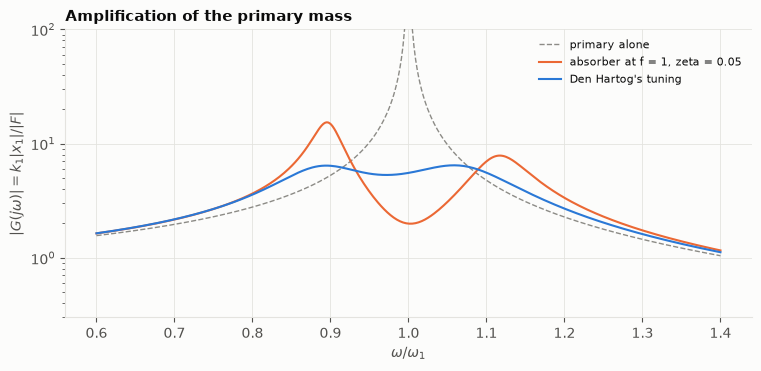

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
alone = np.abs(K1 / (K1 - M1 * W_GRID**2))
ax.semilogy(W_GRID, alone, "--", color=plotstyle.NEUTRAL, lw=1, label="primary alone")
ax.semilogy(W_GRID, gains_start, color=plotstyle.ORANGE, lw=1.5, label="absorber at f = 1, zeta = 0.05")
ax.semilogy(W_GRID, gains_dh, color=plotstyle.BLUE, lw=1.5, label="Den Hartog's tuning")
ax.set_ylim(0.3, 100)
ax.set_xlabel(r"$\omega / \omega_1$")
ax.set_ylabel(r"$|G(j\omega)| = k_1 |x_1| / |F|$")
ax.set_title("Amplification of the primary mass")
ax.legend(fontsize=8)
plt.show()

The absorber splits the primary's resonance into two peaks. Tuned to the primary's own frequency
with little damping, the peaks reach 15.3 and 8.0; Den Hartog's tuning brings them to 6.41 and
6.45. Scaly's magnitudes match NumPy's to $1.2 \times 10^{-15}$.

## Tuning for the smallest peak

The goal is the H-infinity norm over the grid, $\max_\omega |G(j\omega)|$, as a function of
$p = (f, \zeta)$. The maximum is not differentiable where two peaks trade places, which is exactly
at the optimum, so the smooth maximum

$$
s_\beta(p) = g_{\max} + \frac{1}{\beta} \log \sum_k e^{\beta (g_k - g_{\max})}, \qquad g_k = |G(j\omega_k; p)|,
$$

replaces it; it exceeds the maximum by at most $\log(400)/\beta$. Subtracting $g_{\max}$ keeps the
exponentials finite and does not change the value or the gradient. `sc.gradient` runs reverse mode
through the map and the 400 solves, each by its implicit rule, and L-BFGS-B uses it, with $\beta$
raised 10, 100, 1000 and each solve warm-started from the last.

Den Hartog's classical tuning puts the two points that every response curve passes through,
whatever the damping, at equal height:

$$
f = \frac{1}{1 + \mu}, \qquad \zeta = \sqrt{\frac{3\mu}{8 (1 + \mu)^3}}, \qquad |G| = \sqrt{1 + 2/\mu} .
$$

In [6]:
BETAS = (10.0, 100.0, 1000.0)
BOUNDS = [(0.5, 1.5), (0.01, 0.5)]
PEAK_DH = np.sqrt(1 + 2 / MU)


@sc.function(2, (), output=sc.G("smax", "grad_smax_p"))
def fr_smax(p, beta):
  gains = fr_bode(sc.const(W_GRID), p)
  top = gains.max()
  smax = top + (beta * (gains - top)).exp().sum().log() / beta
  return smax, sc.gradient(smax, p)


value, grad = fr_smax(p_dh, np.array(BETAS[1]))
eps = 1e-7  # the smooth maximum curves sharply: at 1e-6 the truncation error is already 4e-7
fd = np.array([(fr_smax(p_dh + e, np.array(BETAS[1]))[0] - fr_smax(p_dh - e, np.array(BETAS[1]))[0]) / (2 * eps) for e in np.eye(2) * eps])
grad_fd_error = float(np.abs(grad - fd).max() / np.abs(fd).max())
print(f"s_100 at Den Hartog's tuning: {float(value):.6f}, gradient {grad.round(5)}")
print(f"central differences: {fd.round(5)}, relative gap {grad_fd_error:.1e}")

s_100 at Den Hartog's tuning: 6.459342, gradient [-43.53045  -8.44887]
central differences: [-43.53045  -8.44887], relative gap 4.3e-09


In [7]:
p, evaluations, path = P_START, 0, [P_START]
print(f"{'beta':>6s} {'f':>9s} {'zeta':>9s} {'s_beta':>9s} {'evaluations':>12s}")
for beta in BETAS:
  result = minimize(
    lambda q, beta=beta: tuple(np.asarray(v, dtype=np.float64) for v in fr_smax(q, np.array(beta))),
    p,
    jac=True,
    method="L-BFGS-B",
    bounds=BOUNDS,
    options={"ftol": 1e-15, "gtol": 1e-10, "maxiter": 500},
    callback=lambda q: path.append(q.copy()),
  )
  p, evaluations = result.x, evaluations + result.nfev
  print(f"{beta:6.0f} {p[0]:9.6f} {p[1]:9.6f} {result.fun:9.5f} {result.nfev:12d}")
p_opt, path = p, np.array(path)
f_opt, zeta_opt = float(p_opt[0]), float(p_opt[1])

  beta         f      zeta    s_beta  evaluations
    10  0.952715  0.132029   6.72867           16
   100  0.952405  0.133757   6.42829           16
  1000  0.952371  0.133986   6.40880           19


In [8]:
def peaks(p):
  """Frequencies and heights of the local maxima of |G|, each refined on a grid of its own around it."""
  gains = fr_bode(W_GRID, p)
  where = np.flatnonzero((gains[1:-1] > gains[:-2]) & (gains[1:-1] >= gains[2:])) + 1
  found = []
  for i in where:
    fine = np.linspace(W_GRID[i - 1], W_GRID[i + 1], N_GRID)
    around = fr_bode(fine, p)
    found.append((fine[around.argmax()], around.max()))
  return np.array([w for w, _ in found]), np.array([g for _, g in found])


peak_w, peak_heights = peaks(p_opt)
dh_w, dh_heights = peaks(p_dh)
print(f"{'':22s} {'f':>9s} {'zeta':>9s} {'peaks':>18s} {'at w':>16s}")
for name, (f, zeta), heights, ws in (("Den Hartog", p_dh, dh_heights, dh_w), ("H-infinity, L-BFGS-B", p_opt, peak_heights, peak_w)):
  print(f"{name:22s} {f:9.5f} {zeta:9.5f} {'  '.join(f'{g:8.5f}' for g in heights):>18s} {'  '.join(f'{w:7.4f}' for w in ws):>16s}")
print(f"Den Hartog's fixed-point height sqrt(1 + 2 / mu) = {PEAK_DH:.5f}; {evaluations} evaluations of value and gradient")

                               f      zeta              peaks             at w
Den Hartog               0.95238   0.12727  6.40594   6.44593  0.8945   1.0584
H-infinity, L-BFGS-B     0.95237   0.13399  6.40801   6.40783  0.8994   1.0524
Den Hartog's fixed-point height sqrt(1 + 2 / mu) = 6.40312; 51 evaluations of value and gradient


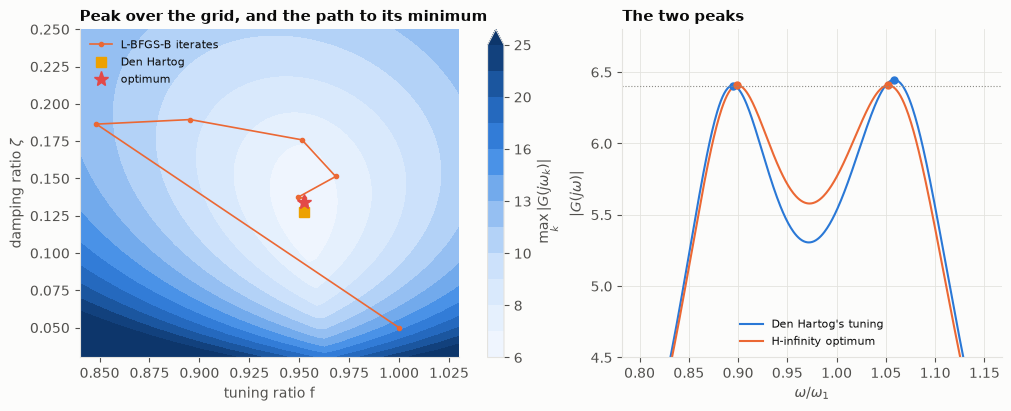

In [9]:
fs, zetas = np.linspace(0.84, 1.03, 49), np.linspace(0.03, 0.25, 45)
top = np.array([[fr_bode(W_GRID, np.array([f, z])).max() for f in fs] for z in zetas])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
levels = np.geomspace(6.4, 25, 13)
contours = ax1.contourf(fs, zetas, top, levels=levels, cmap=plotstyle.BLUES, extend="max")
fig.colorbar(contours, ax=ax1, label=r"$\max_k |G(j\omega_k)|$", format="%.0f")
ax1.plot(path[:, 0], path[:, 1], "o-", color=plotstyle.ORANGE, ms=3, lw=1.2, label="L-BFGS-B iterates")
ax1.plot(*p_dh, "s", color=plotstyle.YELLOW, ms=7, label="Den Hartog")
ax1.plot(*p_opt, "*", color=plotstyle.RED, ms=11, label="optimum")
ax1.set_xlabel("tuning ratio f")
ax1.set_ylabel(r"damping ratio $\zeta$")
ax1.set_title("Peak over the grid, and the path to its minimum")
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(False)
near = np.linspace(0.8, 1.15, N_GRID)
ax2.plot(near, fr_bode(near, p_dh), color=plotstyle.BLUE, lw=1.5, label="Den Hartog's tuning")
ax2.plot(near, fr_bode(near, p_opt), color=plotstyle.ORANGE, lw=1.5, label="H-infinity optimum")
ax2.plot(dh_w, dh_heights, "o", color=plotstyle.BLUE, ms=5)
ax2.plot(peak_w, peak_heights, "o", color=plotstyle.ORANGE, ms=5)
ax2.axhline(PEAK_DH, color=plotstyle.NEUTRAL, lw=0.8, ls=":")
ax2.set_ylim(4.5, 6.8)
ax2.set_xlabel(r"$\omega / \omega_1$")
ax2.set_ylabel(r"$|G(j\omega)|$")
ax2.set_title("The two peaks")
ax2.legend(fontsize=8, loc="lower center")
plt.show()

The gradient matches central differences to $4.3 \times 10^{-9}$. From $f = 1$, $\zeta = 0.05$,
L-BFGS-B needs 51 evaluations of value and gradient over the three values of $\beta$. The optimum
keeps Den Hartog's $f$ to $10^{-5}$ and raises $\zeta$ by 5.3%, to 0.1340. Its two peaks are level,
6.40801 and 6.40783, the last digits being the smooth maximum's bias at $\beta = 1000$. Den Hartog's
own tuning is approximate: its peaks are 6.406 and 6.446, the higher one 0.6% above the optimum's,
while the fixed-point height $\sqrt{1 + 2/\mu} = 6.403$ (dotted) sits just below both. On the left,
the peak over the grid has a crease running up from low damping near $f = 0.95$, where the lower and
the upper peak trade places; the minimum sits on it, Den Hartog's point just below. The first
iterates, at $\beta = 10$, overshoot to $f = 0.85$ before the path settles into the crease.

## Checks

In [10]:
assert sorted(permutation) == list(range(8)) and permutation[0] != 0  # the first pivot needs a row swap
assert lu_solve_error < 1e-13 and adjoint_error < 1e-13 and bode_error < 1e-13
assert grad_fd_error < 5e-8
assert abs(f_opt / F_DH - 1) < 1e-3
assert 0.02 < zeta_opt / ZETA_DH - 1 < 0.1  # the H-infinity optimum damps a little more
assert len(peak_heights) == 2 and abs(peak_heights[0] - peak_heights[1]) / peak_heights.max() < 1e-3  # two equal peaks
assert peak_heights.max() < dh_heights.max() and abs(dh_heights[1] - dh_heights[0]) > 0.02
assert abs(peak_heights.max() / PEAK_DH - 1) < 0.01
assert evaluations < 300
print("all 9 checks passed")

all 9 checks passed


## The generated C

`fr_smax` is the smooth maximum and its gradient as one C function: the 400 solves, each an
$8 \times 8$ LU with partial pivoting written out as straight-line code, run in a loop, and the
reverse sweep through them.

In [11]:
module = write_module(fr_smax, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB, workspace {module.workspace_size} doubles")
print(next(line for line in module.header.splitlines() if line.startswith("int fr_smax(")))

fr_smax.c: 1986 lines, 91 kB, workspace 0 doubles
int fr_smax(const double** arg, double** res, int* iw, double* w, int mem);
